Phase 1.1: Exploratory Data Analysis & Preprocessing Pipeline

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from datasets import load_dataset

# Set the style for seaborn
sns.set_style("whitegrid")

# Load the dataset from Hugging Face (use 'train' split for EDA)
dataset = load_dataset("hpe-ai/medical-cases-classification-tutorial")
df = dataset['train'].to_pandas()

# Display the first few rows of the dataframe
print("First 5 rows of the dataset:")
print(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
print(df.info())

# Check for any missing values
print("\nMissing Values:")
print(df.isnull().sum())

/home/tharu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


First 5 rows of the dataset:
                                         description  \
0  Pacemaker ICD interrogation.  Severe nonischem...   
1  Erythema of the right knee and leg, possible s...   
2  Left cardiac catheterization with selective ri...   
3  Patient with a history of coronary artery dise...   
4  Cardiac evaluation and treatment in a patient ...   

                                       transcription  \
0  PROCEDURE NOTE: , Pacemaker ICD interrogation....   
1  PREOPERATIVE DIAGNOSES: , Erythema of the righ...   
2  PREOPERATIVE DIAGNOSIS: , Post infarct angina....   
3  REASON FOR VISIT: , Acute kidney failure.,HIST...   
4  REASON FOR REFERRAL: , Cardiac evaluation and ...   

                                     sample_name           medical_specialty  \
0                        Pacemaker Interrogation  Cardiovascular / Pulmonary   
1                        Aspiration - Knee Joint                  Orthopedic   
2  Cardiac Cath & Selective Coronary Angiography  Cardiov

2.1 Analyze the Target Variable: 'medical_specialty'

/tmp/ipykernel_62175/268736230.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


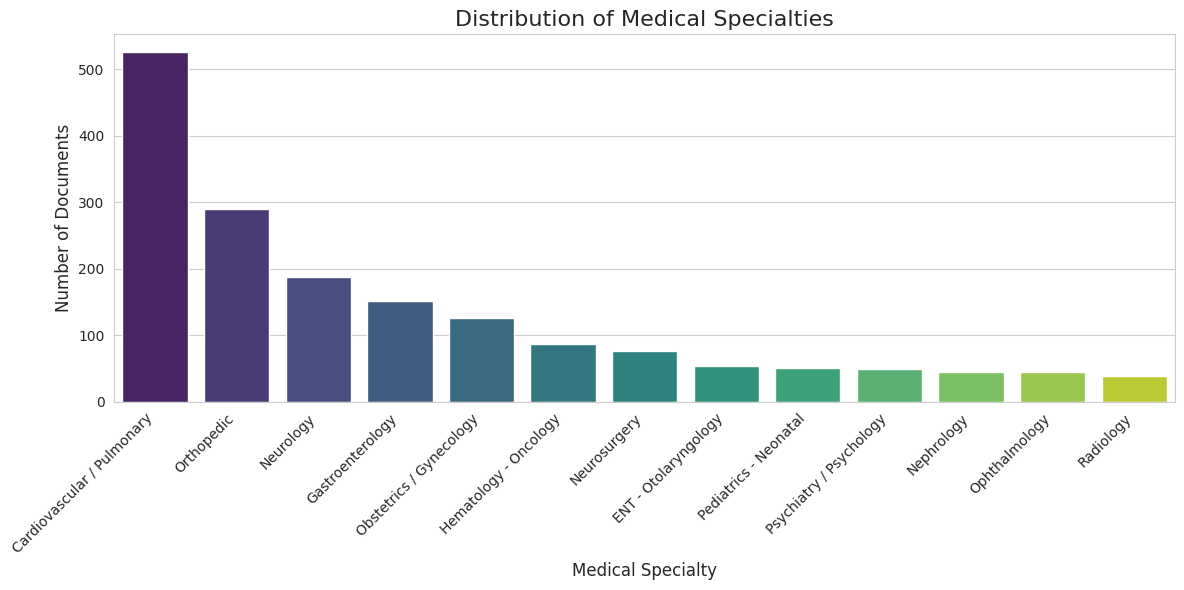


Class Distribution (Medical Specialties):
medical_specialty
Cardiovascular / Pulmonary    526
Orthopedic                    289
Neurology                     187
Gastroenterology              152
Obstetrics / Gynecology       126
Hematology - Oncology          86
Neurosurgery                   76
ENT - Otolaryngology           53
Pediatrics - Neonatal          51
Psychiatry / Psychology        49
Nephrology                     45
Ophthalmology                  45
Radiology                      39
Name: count, dtype: int64


In [2]:
class_counts = df['medical_specialty'].value_counts()

# Create a bar plot for class distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title('Distribution of Medical Specialties', fontsize=16)
plt.xlabel('Medical Specialty', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClass Distribution (Medical Specialties):")
print(class_counts)

2.2 Analyze Text Data: Document Lengths

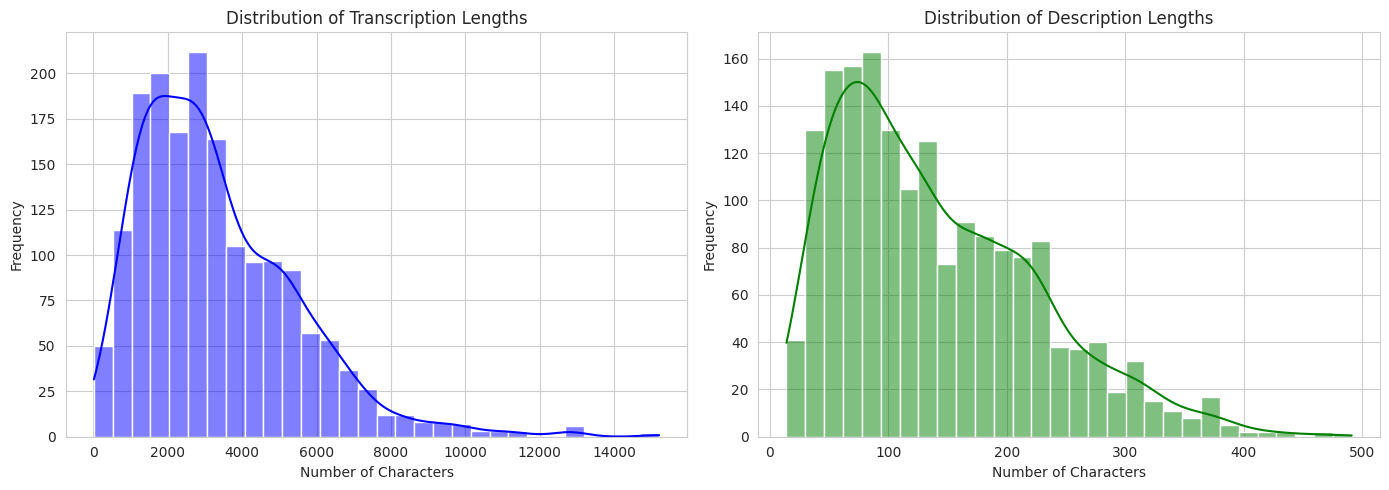


Summary Statistics for Document Lengths:
       transcription_length  description_length
count           1724.000000         1724.000000
mean            3326.159513          140.400232
std             2132.592848           85.101359
min               13.000000           14.000000
25%             1709.000000           73.000000
50%             2850.500000          123.500000
75%             4551.250000          196.000000
max            15216.000000          491.000000


In [3]:
# 2.2 Analyze Text Data: Document Lengths
df['transcription_length'] = df['transcription'].str.len()
df['description_length'] = df['description'].str.len()

# Plot histograms for document lengths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['transcription_length'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Transcription Lengths')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

sns.histplot(df['description_length'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Description Lengths')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nSummary Statistics for Document Lengths:")
print(df[['transcription_length', 'description_length']].describe())

3.1 Define the Text Preprocessing Pipeline using TfidfVectorizer

In [4]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit the vectorizer on the training text data
X = vectorizer.fit_transform(df['transcription'])
y = df['medical_specialty']

print(f"\nShape of the TF-IDF Matrix: {X.shape}")
print(f"Number of documents: {X.shape[0]}")
print(f"Number of unique features (words/bigrams): {X.shape[1]}")

# To see the feature names (the actual words)
feature_names = vectorizer.get_feature_names_out()
print(f"\nFirst 20 feature names: {feature_names[:20]}")


Shape of the TF-IDF Matrix: (1724, 5000)
Number of documents: 1724
Number of unique features (words/bigrams): 5000

First 20 feature names: ['00' '000' '000 epinephrine' '01' '02' '03' '04' '05' '06' '07' '08' '09'
 '10' '10 15' '10 20' '10 blade' '10 cc' '10 cm' '10 days' '10 mg']


3.2 Inspect TF-IDF values for a single document

In [5]:
tfidf_scores_first_doc = X[0].toarray().flatten()
doc_0_df = pd.DataFrame({
    'word': feature_names,
    'tfidf_score': tfidf_scores_first_doc
}).sort_values(by='tfidf_score', ascending=False)

print("\nTop 10 words by TF-IDF score in the first document:")
print(doc_0_df.head(10))


Top 10 words by TF-IDF score in the first document:
              word  tfidf_score
2424        joules     0.383827
3206     pacemaker     0.314984
4891         volts     0.302944
2510          lead     0.240213
4097           set     0.237926
595   beats minute     0.229676
594          beats     0.222568
2858        minute     0.178151
4827   ventricular     0.160045
115             36     0.151697
